# Business Analysis

This notebook presents the main business analysis based on the e-commerce dataset.

The goal is to identify key drivers of growth, customer behavior patterns, and factors affecting customer satisfaction.

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))

from src.data_scope import (
    get_connection,
    load_orders_clean,
    load_order_items_clean
)

conn = get_connection()

orders = load_orders_clean(conn)
items = load_order_items_clean(conn)

orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"])

print("Data loaded successfully")

Data loaded successfully


##  GMV Trend Over Time

Analyze how the total GMV evolves over time to understand platform growth.

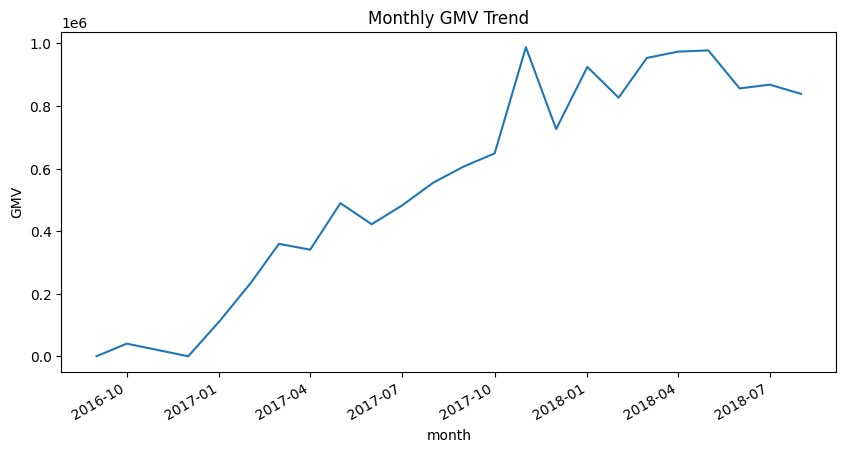

In [2]:
df = items.merge(
    orders[["order_id", "order_purchase_timestamp"]],
    on="order_id",
    how="left"
)

df["month"] = df["order_purchase_timestamp"].dt.to_period("M")

gmv_trend = df.groupby("month")["price"].sum()

gmv_trend.index = gmv_trend.index.to_timestamp()

gmv_trend.plot(figsize=(10,5), title="Monthly GMV Trend")
plt.ylabel("GMV")
plt.show()

### Key Findings

- GMV shows a clear upward trend over time, indicating strong platform growth.
- A noticeable peak appears towards the later period, suggesting possible seasonality or promotional effects.
- After the peak, GMV stabilizes slightly, indicating a potential slowdown in growth.

### Conclusion

The platform experienced rapid growth over the observed period, with signs of seasonality. Sustaining growth may require continued customer acquisition and retention strategies.

## Order Volume and AOV Trend

Analyze how order volume and average order value (AOV) evolve over time to understand the drivers of GMV.

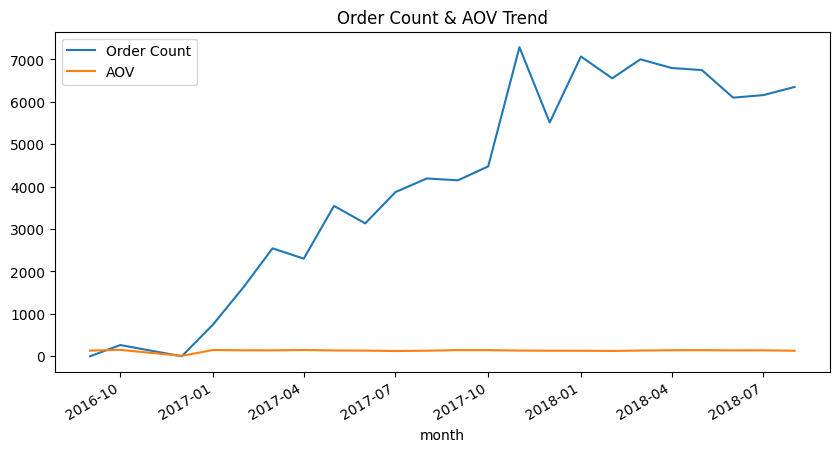

In [3]:
df = items.merge(
    orders[["order_id", "order_purchase_timestamp"]],
    on="order_id",
    how="left"
)

df["month"] = df["order_purchase_timestamp"].dt.to_period("M")

order_count = df.groupby("month")["order_id"].nunique()

gmv = df.groupby("month")["price"].sum()

aov = gmv / order_count

order_count.index = order_count.index.to_timestamp()
aov.index = aov.index.to_timestamp()

fig, ax = plt.subplots(figsize=(10,5))

order_count.plot(ax=ax, label="Order Count")
aov.plot(ax=ax, label="AOV")

plt.legend()
plt.title("Order Count & AOV Trend")
plt.show()

### Key Findings

- Order volume shows a clear increasing trend over time, indicating growing platform activity.
- AOV remains relatively stable with slight fluctuations.
- The growth in GMV is primarily driven by an increase in the number of orders rather than higher spending per order.

### Conclusion

Platform growth is mainly volume-driven rather than price-driven. This suggests that user acquisition and transaction frequency are the key drivers of revenue growth.

## Customer Behavior Analysis: New vs Returning Customers

Analyze how much GMV is contributed by new customers versus returning customers,
and evaluate the overall repeat purchase behavior.

is_new_customer
False      358348.58
True     12863149.53
Name: price, dtype: float64


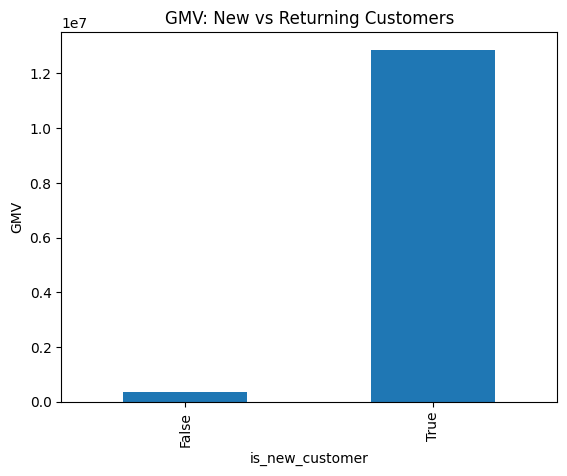

In [4]:
customers = pd.read_sql(
    "SELECT customer_id, customer_unique_id FROM customers",
    conn
)

orders = orders.merge(customers, on="customer_id", how="left")

first_order = orders.groupby("customer_unique_id")["order_purchase_timestamp"].min().reset_index()
first_order.columns = ["customer_unique_id", "first_order_time"]

orders = orders.merge(first_order, on="customer_unique_id", how="left")

orders["is_new_customer"] = (
    orders["order_purchase_timestamp"] == orders["first_order_time"]
)

order_gmv = items.groupby("order_id")["price"].sum().reset_index()

df = order_gmv.merge(
    orders[["order_id", "customer_unique_id", "is_new_customer"]],
    on="order_id",
    how="left"
)

gmv_split = df.groupby("is_new_customer")["price"].sum()

print(gmv_split)

gmv_split.plot(kind="bar", title="GMV: New vs Returning Customers")
plt.ylabel("GMV")
plt.show()

In [5]:
order_counts = orders.groupby("customer_unique_id")["order_id"].nunique()

repeat_rate = (order_counts > 1).mean()

print("Repeat Rate:", repeat_rate)

Repeat Rate: 0.03000278497825575


### Key Findings

- The vast majority of GMV is generated by new customers, while returning customers contribute only a small share.
- The overall repeat purchase rate is approximately 3%, indicating that very few customers make multiple purchases.

### Conclusion

The platform is highly dependent on new customer acquisition for revenue growth, with very weak customer retention.

Most customers make only one purchase and do not return, limiting long-term customer value.

Improving customer retention should be a key priority for sustainable growth.

## Time Between First and Second Purchase

Analyze how long it takes for customers to make a second purchase after their first order.

In [6]:
orders_sorted = orders.sort_values(
    ["customer_unique_id", "order_purchase_timestamp"]
)

orders_sorted["order_rank"] = (
    orders_sorted.groupby("customer_unique_id").cumcount() + 1
)

first_second = orders_sorted[orders_sorted["order_rank"] <= 2]

pivot = first_second.pivot(
    index="customer_unique_id",
    columns="order_rank",
    values="order_purchase_timestamp"
)

pivot = pivot.dropna()

pivot["gap_days"] = (pivot[2] - pivot[1]).dt.days

pivot["gap_days"].describe()

count    2801.000000
mean       80.844698
std       109.899443
min         0.000000
25%         0.000000
50%        28.000000
75%       126.000000
max       608.000000
Name: gap_days, dtype: float64

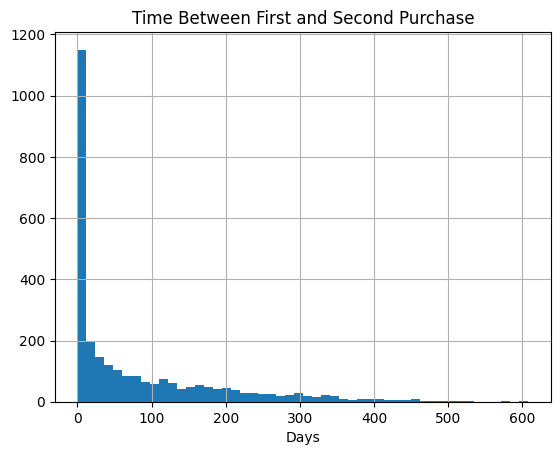

In [7]:
pivot["gap_days"].hist(bins=50)
plt.title("Time Between First and Second Purchase")
plt.xlabel("Days")
plt.show()

### Key Findings

- The median time between the first and second purchase is around one month (~28 days).
- The distribution is right-skewed, with some customers returning much later.
- A portion of customers make repeat purchases very quickly, even within the same day.

### Conclusion

Among customers who do make repeat purchases, most tend to return within a relatively short period.

However, given the overall low repeat rate, this behavior applies to only a small subset of users.

This suggests that while some users are highly engaged, the majority do not return at all.

## Product Performance Analysis

Analyze which product categories contribute most to GMV and how categories differ in terms of sales volume and average price.

In [8]:
products = pd.read_sql(
    "SELECT product_id, product_category_name FROM products",
    conn
)

df = items.merge(products, on="product_id", how="left")

category_stats = df.groupby("product_category_name").agg({
    "price": ["sum", "mean"],
    "order_id": "count"
})

category_stats.columns = ["gmv", "avg_price", "sales_volume"]

category_stats = category_stats.sort_values("gmv", ascending=False)

category_stats.head(10)

,gmv,avg_price,sales_volume
product_category_name,,,
beleza_saude,1258681.34,130.163531,9670
relogios_presentes,1205005.68,201.135984,5991
cama_mesa_banho,1036988.68,93.296327,11115
esporte_lazer,988048.97,114.344285,8641
informatica_acessorios,911954.32,116.513903,7827
moveis_decoracao,729762.49,87.564494,8334
cool_stuff,635290.85,167.357969,3796
utilidades_domesticas,632248.66,90.788148,6964
automotivo,592720.11,139.957523,4235


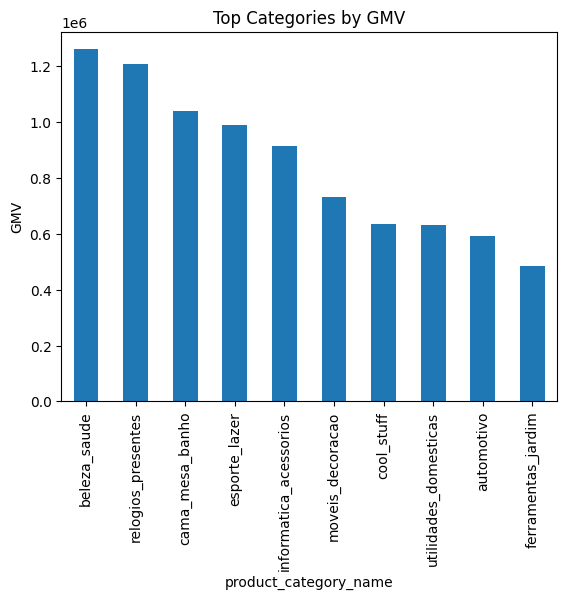

In [9]:
category_stats.head(10)["gmv"].plot(kind="bar", title="Top Categories by GMV")
plt.ylabel("GMV")
plt.show()

### Key Findings

- A small number of product categories contribute a large share of total GMV.
- Categories differ significantly in both sales volume and average price.
- Some categories achieve high GMV through high sales volume, while others rely on higher average prices.

### Conclusion

Different product categories follow distinct revenue patterns: some are volume-driven, while others are price-driven.

Understanding these differences is important for optimizing product strategy and resource allocation across categories.

## Seller Concentration Analysis

Analyze whether the platform exhibits a strong seller concentration effect (e.g., 80/20 rule).

In [10]:
seller_gmv = items.groupby("seller_id")["price"].sum().sort_values(ascending=False)

seller_share = seller_gmv.cumsum() / seller_gmv.sum()

seller_share.head(10)

seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    0.016883
53243585a1d6dc2643021fd1853d8905    0.033274
4a3ca9315b744ce9f8e9374361493884    0.048024
fa1c13f2614d7b5c4749cbc52fecda94    0.062300
7c67e1448b00f6e969d365cea6b010ab    0.076127
7e93a43ef30c4f03f38b393420bc753a    0.089108
da8622b14eb17ae2831f4ac5b9dab84a    0.100897
7a67c85e85bb2ce8582c35f2203ad736    0.111326
1025f0e2d44d7041d6cf58b6550e0bfa    0.121550
955fee9216a65b617aa5c0531780ce60    0.131496
Name: price, dtype: float64

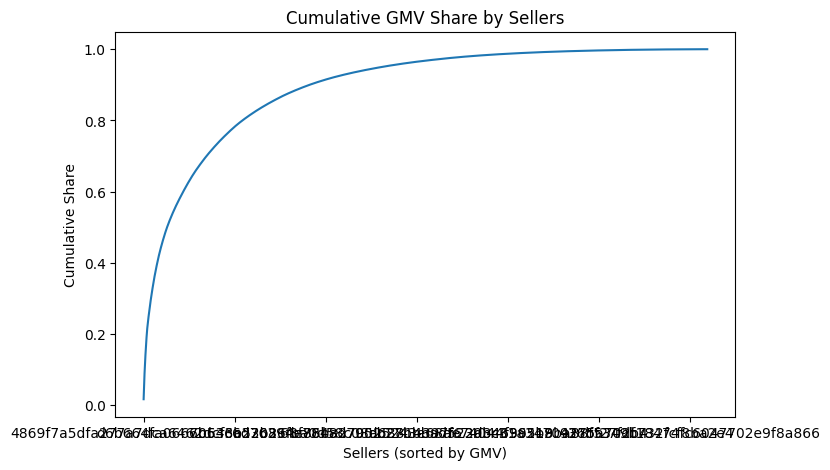

In [11]:
seller_share.plot(figsize=(8,5), title="Cumulative GMV Share by Sellers")
plt.xlabel("Sellers (sorted by GMV)")
plt.ylabel("Cumulative Share")
plt.show()

In [12]:
top_sellers_ratio = (seller_share <= 0.8).sum() / len(seller_share)

print("Top sellers ratio (for 80% GMV):", top_sellers_ratio)

Top sellers ratio (for 80% GMV): 0.1754442649434572


### Key Findings

- A small proportion of sellers contribute the majority of GMV.
- The platform shows a clear long-tail distribution, where most sellers generate relatively low sales.
- Approximately a small percentage of sellers account for 80% of total GMV.
- Approximately 17.5% of sellers contribute to 80% of total GMV, indicating a strong concentration effect.

### Conclusion

The platform exhibits a strong seller concentration effect, indicating reliance on a limited number of top-performing sellers.

This structure suggests potential risk if top sellers leave, but also highlights opportunities to support and grow mid-tier sellers.

## Delivery Impact on Customer Satisfaction

Analyze whether late delivery significantly affects customer review scores.

In [13]:
reviews = pd.read_sql(
    "SELECT order_id, review_score FROM order_reviews",
    conn
)

orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"])

orders["is_late"] = (
    orders["order_delivered_customer_date"] > orders["order_estimated_delivery_date"]
)

df = orders.merge(reviews, on="order_id", how="left")

score_compare = df.groupby("is_late")["review_score"].mean()

print(score_compare)

is_late
False    4.293737
True     2.566494
Name: review_score, dtype: float64


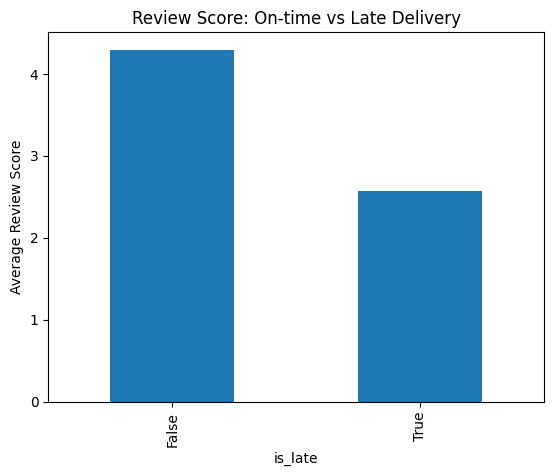

In [14]:
score_compare.plot(kind="bar", title="Review Score: On-time vs Late Delivery")
plt.ylabel("Average Review Score")
plt.show()

In [15]:
df["low_score"] = df["review_score"] <= 2

low_score_rate = df.groupby("is_late")["low_score"].mean()

print(low_score_rate)

is_late
False    0.091842
True     0.528926
Name: low_score, dtype: float64


### Key Findings

- On-time deliveries have an average review score of approximately 4.3, while late deliveries drop significantly to around 2.6.
- This represents a substantial decrease of about 1.7 points on a 5-point scale.
- Late deliveries also show a much higher proportion of low ratings.

### Conclusion

Delivery delay has a strong negative impact on customer satisfaction.

Improving delivery performance is critical to maintaining high customer ratings and overall user experience.